# APR 미국 수요 — Google Trends V3 (앵커 프리)

`apr_us_google_trends_v3.ipynb`

---

## V2의 오류 정정

V2는 `skincare` 를 앵커로 두고 `brand_level = medicube / skincare` 를 핵심 지표로 썼다.
그 결과 "최근 13주 +40.4% → 알파 국면" 이라는 판정이 나왔는데, **이는 잘못이다.**

앵커 `skincare` 가 2026년 초 100까지 치솟았다가 45로 급락했다(변동계수 0.39).
분자가 제자리인데 분모가 25% 빠져 비율이 40% 오른 것이다.
**자(ruler)가 브랜드보다 더 크게 움직였다.**

### 더 근본적인 정정

애초에 **앵커가 필요 없었다.** Google Trends는 **한 번의 호출 안에서는
전 기간에 동일한 스케일**을 적용한다. 따라서 원본값의 YoY는 그 자체로 유효하고,
계절성도 자동 상쇄된다.

앵커가 필요한 경우는 **다른 시점에 재조회한 데이터를 이어붙일 때뿐**이다.
V3는 단일 호출 안에서 완결되는 지표만 쓴다.

## V3의 지표 — 전부 앵커 프리

| 지표 | 정의 | 성격 |
|---|---|---|
| `yoy_52w` | 원본값 52주 YoY | 절대 수요 증감. 계절성 상쇄 |
| `sos` | medicube ÷ (medicube+경쟁사) | 카테고리 내 위치 |
| `vs_peak` | 현재 ÷ 피크 | 사이클 상 위치 |
| `rel_peers` | medicube ÷ 경쟁사 중앙값 | 상대 강도 |

## 경쟁사 재선정

V2는 anua·beauty of joseon 을 썼는데 **넷이 같은 주에 동시 피크**를 찍었다.
선배가 먼저 꺾여야 감쇠 템플릿이 되는데 그러지 못했다.

V3는 **1세대 K뷰티(COSRX, Laneige)** 를 추가한다. 이들이 먼저 피크를 지났다면
진짜 선행 템플릿이 된다.

## 산출물

마지막 장에서 **긍정 근거 / 부정 근거 팩트시트**를 출력한다.
숫자와 출처가 붙은 형태이므로 그대로 인용할 수 있다.

> **주의**: 이 노트북은 미국 검색량만 측정한다. APR 매출에는 일본·중국·내수가 포함되며,
> 검색은 판매가 아니다. 팩트시트의 문장은 "검색량 기준" 이라는 단서를 반드시 유지할 것.

---
**V3** | 2026-08

## 1. 사용자 입력

In [1]:
# ============================================================================
# USER INPUT
# ============================================================================

TARGET = "medicube"

# ---------- 호출 1: 동세대 경쟁 (5개 제한) ----------
CALL_1 = ["medicube", "anua", "beauty of joseon", "cosrx", "laneige"]
PEERS_SAME_GEN = ["anua", "beauty of joseon"]        # 동세대
PEERS_PRIOR_GEN = ["cosrx", "laneige"]               # 1세대 (감쇠 템플릿)

# ---------- 호출 2: 제품 라인 + 카테고리 (medicube 공통항으로 연결) ----------
CALL_2 = ["medicube", "age-r", "medicube pdrn", "korean skincare", "skincare"]
CATEGORY_KW = "korean skincare"
DEVICE_KW = "age-r"

GEO = "US"
TIMEFRAME = "today 5-y"
HL, TZ_OFFSET = "en-US", -540

COLLECT_MODE = "auto"        # 'auto' / 'trendspy' / 'raw'
RUN_CALL_2 = True            # 호출 2 실행 여부

# ---------- 분석 ----------
MIN_VALID_DATE = "2024-01-01"   # 이전 구간은 저볼륨 컷오프로 신뢰 불가
SMOOTH_W = 13                   # 평활 창(주)
SOS_NOISE_BAND = 0.03           # sos 변화가 이 미만이면 '변화 없음'
YOY_WEEKS = 52

# ---------- 네트워크 ----------
REQUEST_TIMEOUT, RETRY_COUNT, RETRY_SLEEP = 30, 3, 5

SHOW_PLOTS = True
FIG_W = 14


## 2. 환경

In [2]:
import os
import sys
import json
import time
import warnings
from datetime import date, datetime
from typing import Optional, Union, List, Dict, Any, Tuple

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)

# ============================================================================
# 경로 자동탐지 — 데스크톱 / 노트북 어디서 실행해도 DATA/ 를 찾아낸다
# ============================================================================
# 탐색 순서:
#   1) BASE_PATH_OVERRIDE (수동 지정)
#   2) 환경변수 STOCK_BASE_PATH
#   3) 현재 작업 디렉토리에서 상위로 6단계
#   4) 알려진 고정 경로
#   5) 홈 디렉토리 기반 얕은 탐색 (OneDrive / 바탕 화면 / Desktop 등)
# ----------------------------------------------------------------------------

BASE_PATH_OVERRIDE = None   # 전부 실패하면 여기에 경로를 직접 문자열로 넣으십시오

KNOWN_PATHS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

PROJECT_DIR_NAMES = ["stock_forecast", "investment_strategy", "investment"]


def _has_data(p: Optional[str]) -> bool:
    if not p:
        return False
    try:
        return os.path.isdir(os.path.join(p, "DATA"))
    except Exception:
        return False


def resolve_base_path() -> Tuple[Optional[str], List[Tuple[str, str]]]:
    """DATA/ 를 포함한 프로젝트 루트를 탐색. (경로, 시도이력) 반환."""
    tried: List[Tuple[str, str]] = []

    # (1) 수동 지정
    if BASE_PATH_OVERRIDE:
        tried.append(("override", BASE_PATH_OVERRIDE))
        if _has_data(BASE_PATH_OVERRIDE):
            return BASE_PATH_OVERRIDE, tried

    # (2) 환경변수
    envp = os.environ.get("STOCK_BASE_PATH")
    if envp:
        tried.append(("env", envp))
        if _has_data(envp):
            return envp, tried

    # (3) cwd에서 상위로 — 노트북이 프로젝트 하위 어디에 있어도 잡힌다
    cur = os.path.abspath(os.getcwd())
    for _ in range(6):
        tried.append(("cwd-up", cur))
        if _has_data(cur):
            return cur, tried
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent

    # (4) 알려진 고정 경로
    for p in KNOWN_PATHS:
        tried.append(("known", p))
        if _has_data(p):
            return p, tried

    # (5) 홈 기반 얕은 탐색 — OneDrive / 한글·영문 바탕화면 변형 모두 대응
    home = os.path.expanduser("~")
    roots = [
        home,
        os.path.join(home, "OneDrive"),
        os.path.join(home, "Desktop"),
        os.path.join(home, "바탕 화면"),
        os.path.join(home, "OneDrive", "Desktop"),
        os.path.join(home, "OneDrive", "바탕 화면"),
        os.path.join(home, "Documents"),
        os.path.join(home, "PyCharmMiscProject"),
    ]
    for root in roots:
        if not os.path.isdir(root):
            continue
        tried.append(("home", root))
        if _has_data(root):
            return root, tried
        for nm in PROJECT_DIR_NAMES:
            cand = os.path.join(root, nm)
            if _has_data(cand):
                return cand, tried
        # 한 단계 더 들어가서 확인
        try:
            for sub in sorted(os.listdir(root)):
                subp = os.path.join(root, sub)
                if not os.path.isdir(subp):
                    continue
                if _has_data(subp):
                    return subp, tried
                for nm in PROJECT_DIR_NAMES:
                    cand = os.path.join(subp, nm)
                    if _has_data(cand):
                        return cand, tried
        except (PermissionError, OSError):
            continue

    return None, tried


BASE_PATH, _tried = resolve_base_path()

if BASE_PATH is None:
    print("=" * 78)
    print("[ERROR] DATA/ 폴더를 포함한 프로젝트 루트를 찾지 못했습니다.")
    print("=" * 78)
    print("\n시도한 경로 (%d개):" % len(_tried))
    for how, p in _tried[:20]:
        print("  [%-8s] %s" % (how, p))
    print("\n해결 방법 — 아래 중 하나:")
    print("  (A) 이 셀 상단의 BASE_PATH_OVERRIDE 에 경로를 직접 입력")
    print(r"      예: BASE_PATH_OVERRIDE = r'D:\work\investment_strategy'")
    print("  (B) 환경변수 STOCK_BASE_PATH 설정 후 Jupyter 재시작")
    print('      PowerShell:  setx STOCK_BASE_PATH "D:\\work\\investment_strategy"')
    print("  (C) KNOWN_PATHS 리스트에 이 PC의 경로를 추가")
    print("\n현재 작업 디렉토리:", os.getcwd())
    BASE_PATH = os.getcwd()
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
else:
    DATA_PATH = os.path.join(BASE_PATH, "DATA")
    print("BASE_PATH :", BASE_PATH)
    print("DATA_PATH :", DATA_PATH)

if DATA_PATH not in sys.path:
    sys.path.append(DATA_PATH)
# config.py 가 `from DATA.stock_invest_function import ...` 형태로 import 하므로
# DATA/ 뿐 아니라 그 부모(프로젝트 루트)도 sys.path 에 있어야 한다.
if BASE_PATH not in sys.path:
    sys.path.insert(0, BASE_PATH)

print("python    :", sys.version.split()[0])
print("pandas    :", pd.__version__)


BASE_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
DATA_PATH : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy\DATA
python    : 3.9.10
pandas    : 2.2.2


## 3. 수집 — trendspy → raw fallback

`pytrends` 는 2025-04 아카이브되어 동작하지 않는다. `trendspy` 를 쓰고,
실패 시 내부 엔드포인트를 직접 호출한다.

In [3]:
def fetch_via_trendspy(kws: List[str], geo: str, tf: str) -> Optional[pd.DataFrame]:
    try:
        from trendspy import Trends
    except ImportError:
        print("[trendspy] 미설치 → pip install trendspy")
        return None
    try:
        df = Trends().interest_over_time(kws, timeframe=tf, geo=geo)
    except Exception as e:
        print("[trendspy] 실패:", repr(e)[:150]); return None
    if df is None or len(df) == 0:
        return None

    df = df.copy()
    pc = None
    for c in list(df.columns):
        if str(c).lower().replace("_", "") in ("ispartial", "partial"):
            pc = c; break
    df["_is_partial"] = df[pc].astype(bool) if pc is not None else False
    if pc is not None:
        df = df.drop(columns=[pc])
    if not isinstance(df.index, pd.DatetimeIndex):
        for c in ["date", "time", "Date"]:
            if c in df.columns:
                df = df.set_index(pd.to_datetime(df[c])).drop(columns=[c]); break
    df.index = pd.to_datetime(df.index)
    keep = [k for k in kws if k in df.columns]
    if not keep:
        return None
    print("[trendspy] %d행 × %d키워드" % (len(df), len(keep)))
    return df[keep + ["_is_partial"]]


_UA = ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
       "(KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36")
_BASE = "https://trends.google.com"


def _xssi(t: str) -> Dict[str, Any]:
    i = t.find("{")
    if i < 0:
        raise ValueError("JSON 없음")
    return json.loads(t[i:])


def fetch_via_raw(kws: List[str], geo: str, tf: str) -> Optional[pd.DataFrame]:
    import requests
    s = requests.Session()
    s.headers.update({"User-Agent": _UA, "Accept-Language": "en-US,en;q=0.9",
                      "Referer": _BASE + "/trends/explore"})
    try:
        s.get(_BASE + "/trends/explore", timeout=REQUEST_TIMEOUT)
    except Exception as e:
        print("[raw] 쿠키 warm-up 실패:", repr(e)[:120]); return None

    req = {"comparisonItem": [{"keyword": k, "geo": geo, "time": tf} for k in kws],
           "category": 0, "property": ""}
    prm = {"hl": HL, "tz": str(TZ_OFFSET), "req": json.dumps(req, separators=(",", ":"))}

    widget = None
    for a in range(RETRY_COUNT):
        try:
            r = s.get(_BASE + "/trends/api/explore", params=prm, timeout=REQUEST_TIMEOUT)
            if r.status_code != 200:
                time.sleep(RETRY_SLEEP); continue
            for w in _xssi(r.text).get("widgets", []):
                if w.get("id") == "TIMESERIES":
                    widget = w; break
            if widget:
                break
        except Exception:
            time.sleep(RETRY_SLEEP)
    if not widget:
        print("[raw] TIMESERIES 위젯 실패"); return None

    mp = {"hl": HL, "tz": str(TZ_OFFSET),
          "req": json.dumps(widget["request"], separators=(",", ":")),
          "token": widget["token"]}
    payload = None
    for a in range(RETRY_COUNT):
        try:
            r = s.get(_BASE + "/trends/api/widgetdata/multiline", params=mp,
                      timeout=REQUEST_TIMEOUT)
            if r.status_code != 200:
                time.sleep(RETRY_SLEEP); continue
            payload = _xssi(r.text); break
        except Exception:
            time.sleep(RETRY_SLEEP)
    if not payload:
        return None

    rows = []
    for pt in payload.get("default", {}).get("timelineData", []):
        try:
            ts = pd.to_datetime(int(pt["time"]), unit="s")
        except Exception:
            continue
        v = pt.get("value", [])
        rec = {"date": ts, "_is_partial": bool(pt.get("isPartial", False))}
        for i, k in enumerate(kws):
            rec[k] = v[i] if i < len(v) else np.nan
        rows.append(rec)
    if not rows:
        return None
    out = pd.DataFrame(rows).set_index("date").sort_index()
    print("[raw] %d행" % len(out))
    return out


def collect(kws: List[str]) -> Tuple[pd.DataFrame, str]:
    df, src = None, "none"
    if COLLECT_MODE in ("auto", "trendspy"):
        df = fetch_via_trendspy(kws, GEO, TIMEFRAME)
        if df is not None:
            src = "trendspy"
    if df is None and COLLECT_MODE in ("auto", "raw"):
        df = fetch_via_raw(kws, GEO, TIMEFRAME)
        if df is not None:
            src = "raw"
    if df is None:
        raise RuntimeError("수집 실패. pip install trendspy 또는 잠시 후 재시도.")
    return df, src


d1, src1 = collect(CALL_1)
print("[호출1] %s | %s ~ %s" % (src1, d1.index.min().date(), d1.index.max().date()))

d2, src2 = (collect(CALL_2) if RUN_CALL_2 else (pd.DataFrame(), "skip"))
if len(d2):
    print("[호출2] %s" % src2)



[trendspy] 실패: HTTPError('429 Client Error: unknown for url: https://trends.google.com/trends/api/widgetdata/multiline?req=%7B%22time%22%3A+%222021-08-03+2026-08-03%
[raw] 262행
[호출1] raw | 2021-08-01 ~ 2026-08-02
[trendspy] 262행 × 5키워드
[호출2] trendspy


## 4. 전처리 — 유효 구간 확정

2024년 이전은 검색량이 임계 미만이라 0으로 절삭된 구간이 많다
(V2에서 medicube 32%, anua 38%). 그 구간의 비율 지표는
`1/(1+1)=0.5` 같은 정수 나눗셈 아티팩트이므로 해석해서는 안 된다.

In [4]:
def prep(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()
    if "_is_partial" in d.columns:
        d = d.loc[~d["_is_partial"].astype(bool)].drop(columns=["_is_partial"])
    return d


w1 = prep(d1)
w2 = prep(d2) if len(d2) else pd.DataFrame()

qc = pd.DataFrame({
    "n": w1.notna().sum(),
    "zero_ratio": (w1 == 0).mean(),
    "mean": w1.mean(),
    "max": w1.max(),
})
print("=" * 70)
print("데이터 품질 (호출1)")
print("=" * 70)
print(qc.round(3).to_string())

VALID_FROM = pd.to_datetime(MIN_VALID_DATE)
# 타깃이 0을 벗어난 첫 시점과 비교해 더 늦은 쪽을 채택
nz = w1[TARGET][w1[TARGET] > 0]
if len(nz):
    VALID_FROM = max(VALID_FROM, nz.index.min())

v1 = w1.loc[w1.index >= VALID_FROM]
v2 = w2.loc[w2.index >= VALID_FROM] if len(w2) else pd.DataFrame()
print("\n유효 분석 구간: %s ~ %s (%d주)"
      % (v1.index.min().date(), v1.index.max().date(), len(v1)))
zr = float((v1[TARGET] == 0).mean())
print("  구간 내 타깃 0 비율: %.1f%%" % (zr * 100))
if zr > 0.05:
    print("  ! 여전히 0이 섞여 있습니다. MIN_VALID_DATE 를 늦추십시오.")


데이터 품질 (호출1)
                    n  zero_ratio    mean  max
medicube          261       0.008  12.092  100
anua              261       0.345   7.100   48
beauty of joseon  261       0.096   6.670   34
cosrx             261       0.000   8.180   48
laneige           261       0.000  14.050   48

유효 분석 구간: 2024-01-07 ~ 2026-07-26 (134주)
  구간 내 타깃 0 비율: 0.0%


## 5. 앵커 프리 지표

전부 단일 호출 안에서 완결된다. 외부 기준자에 의존하지 않는다.

In [5]:
def smooth(s: pd.Series, w: int = None) -> pd.Series:
    return s.rolling(w or SMOOTH_W, min_periods=max(2, (w or SMOOTH_W) // 3)).mean()


met = pd.DataFrame(index=v1.index)

# (1) 절대 수요 YoY — 앵커 불필요, 계절성 상쇄
met["raw"] = v1[TARGET]
met["raw_sm"] = smooth(v1[TARGET])
# 기저가 0이면 pct_change 가 inf 를 낸다 (저볼륨 컷오프 구간의 잔재).
# inf 는 결측으로 처리해야 이후 평균·표시가 오염되지 않는다.
met["yoy_52w"] = v1[TARGET].pct_change(YOY_WEEKS).replace([np.inf, -np.inf], np.nan)
met["yoy_sm"] = smooth(met["yoy_52w"])

# (2) 동세대 점유율
peers_now = [k for k in PEERS_SAME_GEN if k in v1.columns]
den = v1[TARGET].astype(float).copy()
for k in peers_now:
    den = den + v1[k].astype(float)
met["sos"] = v1[TARGET] / den.replace(0, np.nan)
met["sos_sm"] = smooth(met["sos"])

# (3) 경쟁사 대비 상대 강도
if peers_now:
    met["rel_peers"] = v1[TARGET] / v1[peers_now].median(axis=1).replace(0, np.nan)
    met["rel_peers_sm"] = smooth(met["rel_peers"])

# (4) 1세대 대비
prior_now = [k for k in PEERS_PRIOR_GEN if k in v1.columns]
if prior_now:
    met["rel_prior"] = v1[TARGET] / v1[prior_now].median(axis=1).replace(0, np.nan)
    met["rel_prior_sm"] = smooth(met["rel_prior"])

# (5) 피크 대비
pk = met["raw_sm"].max()
met["vs_peak"] = met["raw_sm"] / pk if pk else np.nan

print("=" * 84)
print("앵커 프리 지표 — 최근 8주")
print("=" * 84)
cols = [c for c in ["raw", "yoy_52w", "sos", "rel_peers", "rel_prior", "vs_peak"]
        if c in met.columns]
print(met[cols].tail(8).round(3).to_string())


앵커 프리 지표 — 최근 8주
            raw  yoy_52w    sos  rel_peers  rel_prior  vs_peak
date                                                          
2026-06-07   64    3.571  0.508      2.065      3.368    0.917
2026-06-14   67    3.786  0.558      2.528      3.722    0.952
2026-06-21  100    5.667  0.606      3.077      4.762    1.000
2026-06-28   55    3.231  0.579      2.750      4.783    0.978
2026-07-05   42    0.400  0.538      2.333      3.818    0.931
2026-07-12   37    0.370  0.578      2.741      4.353    0.865
2026-07-19   40    0.429  0.606      3.077      4.444    0.824
2026-07-26   47    0.741  0.635      3.481      5.875    0.807


In [6]:
# ---------------------------------------------------------------- 구간 비교
def window_avg(s: pd.Series, back: int, width: int = 13) -> float:
    s = s.replace([np.inf, -np.inf], np.nan)
    seg = s.iloc[-(back + width):-back] if back else s.iloc[-width:]
    seg = seg.dropna()
    return float(seg.mean()) if len(seg) else np.nan


print("=" * 78)
print("구간 비교 (13주 평균)")
print("=" * 78)
rows = []
# 주의: yoy_52w 는 이미 변화율이다. 그 값의 QoQ/YoY 를 또 계산하면
#       분모가 0 근처일 때 inf 가 나오고 해석도 불가능하다. 레벨만 표시한다.
RATE_LIKE = {"yoy_52w"}

for name, col in [("절대 검색량", "raw"), ("YoY(52주)", "yoy_52w"),
                  ("동세대 점유율", "sos"), ("경쟁사 대비", "rel_peers"),
                  ("1세대 대비", "rel_prior")]:
    if col not in met.columns:
        continue
    now = window_avg(met[col], 0)
    p13 = window_avg(met[col], 13)
    p52 = window_avg(met[col], 52)
    if col in RATE_LIKE:
        # 변화율 지표는 레벨 차이(%p)로 표시
        rows.append({"지표": name, "최근13주": now, "13주전": p13, "1년전": p52,
                     "QoQ": np.nan, "YoY": np.nan,
                     "비고": "%+.0f%%p vs 13주전" % ((now - p13) * 100)
                     if pd.notna(p13) else ""})
        continue
    rows.append({"지표": name, "최근13주": now, "13주전": p13, "1년전": p52,
                 "QoQ": (now / p13 - 1) if p13 and pd.notna(p13) else np.nan,
                 "YoY": (now / p52 - 1) if p52 and pd.notna(p52) else np.nan,
                 "비고": ""})

cmp_df = pd.DataFrame(rows)
disp = cmp_df.copy()
for c in ["최근13주", "13주전", "1년전"]:
    disp[c] = disp[c].map(lambda x: "%.3f" % x if pd.notna(x) else "-")
for c in ["QoQ", "YoY"]:
    disp[c] = disp[c].map(lambda x: "%+.1f%%" % (x * 100) if pd.notna(x) else "-")
print(disp.to_string(index=False))
print()
print("  ※ sos 변화가 ±%.0f%% 이내면 '변화 없음'으로 해석하십시오 (노이즈 대역)."
      % (SOS_NOISE_BAND * 100))


구간 비교 (13주 평균)
      지표  최근13주   13주전    1년전    QoQ     YoY            비고
  절대 검색량 60.000 52.000 18.462 +15.4% +225.0%              
YoY(52주)  2.769  2.426  2.750      -       - +34%p vs 13주전
 동세대 점유율  0.564  0.556  0.444  +1.3%  +26.9%              
  경쟁사 대비  2.615  2.527  1.622  +3.5%  +61.3%              
  1세대 대비  3.800  2.426  1.635 +56.7% +132.5%              

  ※ sos 변화가 ±3% 이내면 '변화 없음'으로 해석하십시오 (노이즈 대역).


## 6. 사이클 위치 — 1세대가 템플릿

V2는 anua·beauty of joseon 을 템플릿으로 쓰려 했으나 **넷이 동시 피크**여서 실패했다.
선배가 먼저 꺾여야 후행 감쇠를 가늠할 수 있다.

COSRX·Laneige 가 메디큐브보다 앞서 피크를 지났다면, 그 감쇠 속도가
메디큐브의 미래 시나리오가 된다.

In [7]:
def cycle_profile(s: pd.Series, name: str) -> Dict[str, Any]:
    s = smooth(s.loc[s.index >= VALID_FROM]).dropna()
    if len(s) < 30:
        return {"keyword": name, "note": "관측 부족"}
    pk_dt, pk_v = s.idxmax(), s.max()
    res = {"keyword": name, "피크시점": pk_dt.date(), "피크값": round(float(pk_v), 1),
           "피크후주수": int((s.index.max() - pk_dt).days / 7),
           "현재/피크": round(float(s.iloc[-1] / pk_v), 3) if pk_v else np.nan}
    for m in (3, 6, 12):
        tgt = pk_dt + pd.DateOffset(months=m)
        af = s.loc[s.index >= tgt]
        res["피크후%dM" % m] = round(float(af.iloc[0] / pk_v), 3) if len(af) and pk_v else np.nan
    return res


rows = [cycle_profile(v1[k], k) for k in v1.columns if k in CALL_1]
cyc = pd.DataFrame(rows)
print("=" * 92)
print("사이클 프로파일 — 피크 시점과 감쇠")
print("=" * 92)
print(cyc.to_string(index=False))

print()
tgt_row = cyc[cyc["keyword"] == TARGET]
if len(tgt_row):
    t = tgt_row.iloc[0]
    print("  [%s] 피크 %s / 이후 %d주 경과 / 현재 피크의 %.0f%%"
          % (TARGET, t["피크시점"], t["피크후주수"], t["현재/피크"] * 100))

    lead = cyc[(cyc["keyword"].isin(PEERS_PRIOR_GEN)) &
               (pd.to_datetime(cyc["피크시점"]) < pd.to_datetime(t["피크시점"]))]
    if len(lead):
        print()
        print("  [선행 브랜드 감쇠 템플릿]")
        for _, r in lead.iterrows():
            wk = (pd.to_datetime(t["피크시점"]) - pd.to_datetime(r["피크시점"])).days / 7
            print("    %-18s 피크 %s (%.0f주 앞섬) → 6M %s / 12M %s"
                  % (r["keyword"], r["피크시점"], wk,
                     ("%.0f%%" % (r["피크후6M"] * 100)) if pd.notna(r.get("피크후6M")) else "n/a",
                     ("%.0f%%" % (r["피크후12M"] * 100)) if pd.notna(r.get("피크후12M")) else "n/a"))
        print()
        print("    → 이 감쇠율이 %s 의 향후 시나리오 참고치입니다." % TARGET)
    else:
        print()
        print("  ! 선행 브랜드가 없습니다 (전부 동시 또는 이후 피크).")
        print("    동시 피크는 브랜드 로테이션이 아니라 카테고리 전체의 계절·시스템 효과를")
        print("    시사합니다. 개별 브랜드 신호로 해석하지 마십시오.")


사이클 프로파일 — 피크 시점과 감쇠
         keyword       피크시점  피크값  피크후주수  현재/피크  피크후3M  피크후6M  피크후12M
        medicube 2026-06-21 74.3      5  0.807    NaN    NaN     NaN
            anua 2026-06-21 33.9      5  0.764    NaN    NaN     NaN
beauty of joseon 2026-06-21 27.1      5  0.784    NaN    NaN     NaN
           cosrx 2026-06-14 28.7      6  0.614    NaN    NaN     NaN
         laneige 2025-01-05 30.4     81  0.552  0.565  0.458   0.638

  [medicube] 피크 2026-06-21 / 이후 5주 경과 / 현재 피크의 81%

  [선행 브랜드 감쇠 템플릿]
    cosrx              피크 2026-06-14 (1주 앞섬) → 6M n/a / 12M n/a
    laneige            피크 2025-01-05 (76주 앞섬) → 6M 46% / 12M 64%

    → 이 감쇠율이 medicube 의 향후 시나리오 참고치입니다.


## 7. 제품 라인 분해 (호출 2)

`medicube` 를 공통항으로 두 호출을 연결한다. 디바이스(AGE-R)와 스킨케어는
가격대·재구매 주기가 달라 별도로 봐야 한다.

In [8]:
line = pd.DataFrame()

if len(v2):
    scale = (v1[TARGET].reindex(v2.index).mean() / v2[TARGET].mean()) \
        if v2[TARGET].mean() else 1.0
    line = pd.DataFrame(index=v2.index)
    for k in CALL_2:
        if k in v2.columns:
            line[k] = v2[k] * scale

    print("=" * 78)
    print("제품 라인 (medicube 기준 스케일 연결, 배율 %.2f)" % scale)
    print("=" * 78)
    rows = []
    for k in CALL_2:
        if k not in line.columns:
            continue
        s = smooth(line[k]).dropna()
        if len(s) < 20:
            continue
        now = float(s.iloc[-1])
        p13 = float(s.iloc[-14]) if len(s) > 14 else np.nan
        p52 = float(s.iloc[-53]) if len(s) > 53 else np.nan
        rows.append({"키워드": k, "현재": round(now, 2),
                     "QoQ": (now / p13 - 1) if p13 else np.nan,
                     "YoY": (now / p52 - 1) if p52 else np.nan,
                     "피크대비": round(now / s.max(), 3) if s.max() else np.nan})
    ld = pd.DataFrame(rows)
    for c in ["QoQ", "YoY"]:
        ld[c] = ld[c].map(lambda x: "%+.0f%%" % (x * 100) if pd.notna(x) else "-")
    print(ld.to_string(index=False))
    print()
    print("  AGE-R(디바이스)이 브랜드 전체보다 빠르게 식으면 고가 라인 수요 둔화 신호입니다.")
else:
    print("[제품 라인] 호출 2 미실행")


제품 라인 (medicube 기준 스케일 연결, 배율 3.04)
            키워드     현재  QoQ    YoY  피크대비
       medicube  59.57 +14%  +215% 0.804
          age-r   3.04 +18%      - 0.591
  medicube pdrn  10.51 +45% +1400% 0.804
korean skincare  11.21 -17%   +50% 0.800
       skincare 177.54 -15%   +50% 0.788

  AGE-R(디바이스)이 브랜드 전체보다 빠르게 식으면 고가 라인 수요 둔화 신호입니다.


## 8. 팩트시트 — 콘텐츠용 근거

긍정 근거와 부정 근거를 **숫자와 함께** 나열한다.
어느 쪽이 많은지 세는 것이 목적이 아니라, **양쪽을 다 제시**하는 것이 목적이다.

> 모든 문장에 "미국 검색량 기준" 이라는 단서가 붙어 있다. 이 단서를 떼면
> 사실이 아닌 주장이 된다. 인용 시 반드시 유지할 것.

In [9]:
POS, NEG, NEU = [], [], []


def pct(x):
    return "%+.1f%%" % (x * 100) if pd.notna(x) else "n/a"


g = cmp_df.set_index("지표") if len(cmp_df) else pd.DataFrame()

# ---- 절대 수요
if "절대 검색량" in g.index:
    r = g.loc["절대 검색량"]
    if pd.notna(r["YoY"]):
        line_ = ("미국 'medicube' 검색량이 1년 전 대비 %s (13주 평균 기준)"
                 % pct(r["YoY"]))
        (POS if r["YoY"] > 0.10 else NEG if r["YoY"] < -0.10 else NEU).append(line_)
    if pd.notna(r["QoQ"]):
        line_ = "직전 13주 대비 %s" % pct(r["QoQ"])
        (POS if r["QoQ"] > 0.05 else NEG if r["QoQ"] < -0.05 else NEU).append(line_)

# ---- YoY 추세 (가속/감속)
if "YoY(52주)" in g.index:
    r = g.loc["YoY(52주)"]
    now, p13 = r["최근13주"], r["13주전"]
    if pd.notna(now) and pd.notna(p13) and np.isfinite(now) and np.isfinite(p13):
        d_ = now - p13
        NEU.append("검색량 성장률(52주 YoY)이 %.0f%% → %.0f%% (%+.0f%%p)"
                   % (p13 * 100, now * 100, d_ * 100))
        if d_ < -0.15:
            NEG.append("성장률이 %.0f%%p 둔화 — 레벨은 높으나 기울기는 꺾이는 중"
                       % (d_ * 100))
        elif d_ > 0.15:
            POS.append("성장률이 %.0f%%p 가속" % (d_ * 100))

# ---- 점유율
if "동세대 점유율" in g.index:
    r = g.loc["동세대 점유율"]
    lvl = r["최근13주"]
    NEU.append("동세대 K뷰티 3사(medicube·anua·beauty of joseon) 검색 중 "
               "medicube 비중 %.0f%%" % (lvl * 100))
    if pd.notna(r["QoQ"]):
        if abs(r["QoQ"]) < SOS_NOISE_BAND:
            NEG.append("점유율이 %.0f%% 에서 정체 (직전 대비 %s, 노이즈 범위) — "
                       "동세대 내 점유율 확대 국면은 사실상 종료"
                       % (lvl * 100, pct(r["QoQ"])))
        elif r["QoQ"] > 0:
            POS.append("동세대 점유율이 직전 13주 대비 %s 상승" % pct(r["QoQ"]))
        else:
            NEG.append("동세대 점유율이 직전 13주 대비 %s 하락" % pct(r["QoQ"]))

# ---- 상대 강도
for label, key in [("경쟁사 대비", "경쟁사 대비"), ("1세대 대비", "1세대 대비")]:
    if key in g.index:
        r = g.loc[key]
        if pd.notna(r["YoY"]):
            line_ = "%s 상대 강도 1년 전 대비 %s" % (label, pct(r["YoY"]))
            (POS if r["YoY"] > 0.05 else NEG if r["YoY"] < -0.05 else NEU).append(line_)

# ---- 사이클
if len(cyc) and TARGET in set(cyc["keyword"]):
    t = cyc[cyc["keyword"] == TARGET].iloc[0]
    vp = t["현재/피크"]
    NEU.append("검색량 피크는 %s, 이후 %d주 경과" % (t["피크시점"], t["피크후주수"]))
    if pd.notna(vp):
        if vp >= 0.85:
            POS.append("현재 검색량이 피크의 %.0f%% 수준으로 고점권 유지" % (vp * 100))
        elif vp < 0.60:
            NEG.append("현재 검색량이 피크의 %.0f%% 로 하락" % (vp * 100))
        else:
            NEU.append("현재 검색량은 피크의 %.0f%%" % (vp * 100))

    # 동시 피크 여부
    pk_dates = pd.to_datetime(cyc["피크시점"])
    if (pk_dates.max() - pk_dates.min()).days <= 21:
        NEU.append("경쟁사와 카테고리 키워드가 모두 같은 시기에 피크 — "
                   "개별 브랜드 요인이 아니라 카테고리 전체의 계절·시스템 효과일 가능성")
    else:
        peers_decay = cyc[cyc["keyword"].isin(PEERS_SAME_GEN)]["현재/피크"].mean()
        if pd.notna(peers_decay) and pd.notna(vp):
            if vp > peers_decay:
                POS.append("피크 대비 잔존율이 동세대 경쟁사 평균(%.0f%%)보다 높은 %.0f%%"
                           % (peers_decay * 100, vp * 100))
            else:
                NEG.append("피크 대비 잔존율이 동세대 경쟁사 평균(%.0f%%)보다 낮은 %.0f%%"
                           % (peers_decay * 100, vp * 100))

# ---- 카테고리
if len(v2) and CATEGORY_KW in v2.columns:
    cs = smooth(v2[CATEGORY_KW]).dropna()
    if len(cs) > 53:
        cy = cs.iloc[-1] / cs.iloc[-53] - 1
        line_ = "'korean skincare' 카테고리 검색 1년 전 대비 %s" % pct(cy)
        (POS if cy > 0.10 else NEG if cy < -0.10 else NEU).append(line_)

# ---- 디바이스
if len(line) and DEVICE_KW in line.columns:
    ds = smooth(line[DEVICE_KW]).dropna()
    if len(ds) > 53:
        dy = ds.iloc[-1] / ds.iloc[-53] - 1
        line_ = "AGE-R(디바이스) 검색 1년 전 대비 %s" % pct(dy)
        (POS if dy > 0.10 else NEG if dy < -0.10 else NEU).append(line_)

# ---------------------------------------------------------------- 출력
print("=" * 80)
print("APR 미국 수요 팩트시트 — %s 기준" % date.today())
print("=" * 80)
print("\n[긍정 근거]")
print("\n".join("  %d. %s" % (i, s) for i, s in enumerate(POS, 1)) or "  (없음)")
print("\n[부정 근거]")
print("\n".join("  %d. %s" % (i, s) for i, s in enumerate(NEG, 1)) or "  (없음)")
print("\n[중립·맥락]")
print("\n".join("  %d. %s" % (i, s) for i, s in enumerate(NEU, 1)) or "  (없음)")

print()
print("-" * 80)
print("반드시 함께 밝혀야 할 한계")
print("-" * 80)
print("  · 미국 Google 검색량만 측정. APR 매출에는 일본·중국·내수가 포함됨")
print("  · Amazon 내부 검색과 TikTok 인앱 구매는 포착되지 않음")
print("  · 검색은 구매가 아님. 관심과 매출 사이에 채널·전환율 변수가 있음")
print("  · Google Trends는 절대량이 아닌 상대지수. 타 브랜드와의 비교만 유효")
print("  · 표기 변형(medicube / medi cube / 메디큐브)은 별도 집계됨")
print("  · 데이터 출처: Google Trends, %s, 수집일 %s"
      % (TIMEFRAME, date.today()))
print("=" * 80)


APR 미국 수요 팩트시트 — 2026-08-03 기준

[긍정 근거]
  1. 미국 'medicube' 검색량이 1년 전 대비 +225.0% (13주 평균 기준)
  2. 직전 13주 대비 +15.4%
  3. 성장률이 34%p 가속
  4. 경쟁사 대비 상대 강도 1년 전 대비 +61.3%
  5. 1세대 대비 상대 강도 1년 전 대비 +132.5%
  6. 피크 대비 잔존율이 동세대 경쟁사 평균(77%)보다 높은 81%
  7. 'korean skincare' 카테고리 검색 1년 전 대비 +50.0%
  8. AGE-R(디바이스) 검색 1년 전 대비 +inf%

[부정 근거]
  1. 점유율이 56% 에서 정체 (직전 대비 +1.3%, 노이즈 범위) — 동세대 내 점유율 확대 국면은 사실상 종료

[중립·맥락]
  1. 검색량 성장률(52주 YoY)이 243% → 277% (+34%p)
  2. 동세대 K뷰티 3사(medicube·anua·beauty of joseon) 검색 중 medicube 비중 56%
  3. 검색량 피크는 2026-06-21, 이후 5주 경과
  4. 현재 검색량은 피크의 81%

--------------------------------------------------------------------------------
반드시 함께 밝혀야 할 한계
--------------------------------------------------------------------------------
  · 미국 Google 검색량만 측정. APR 매출에는 일본·중국·내수가 포함됨
  · Amazon 내부 검색과 TikTok 인앱 구매는 포착되지 않음
  · 검색은 구매가 아님. 관심과 매출 사이에 채널·전환율 변수가 있음
  · Google Trends는 절대량이 아닌 상대지수. 타 브랜드와의 비교만 유효
  · 표기 변형(medicube / medi cube / 메디큐브)은 별도 집계됨
  · 데이터 출처: Google Trends,

## 9. 시각화

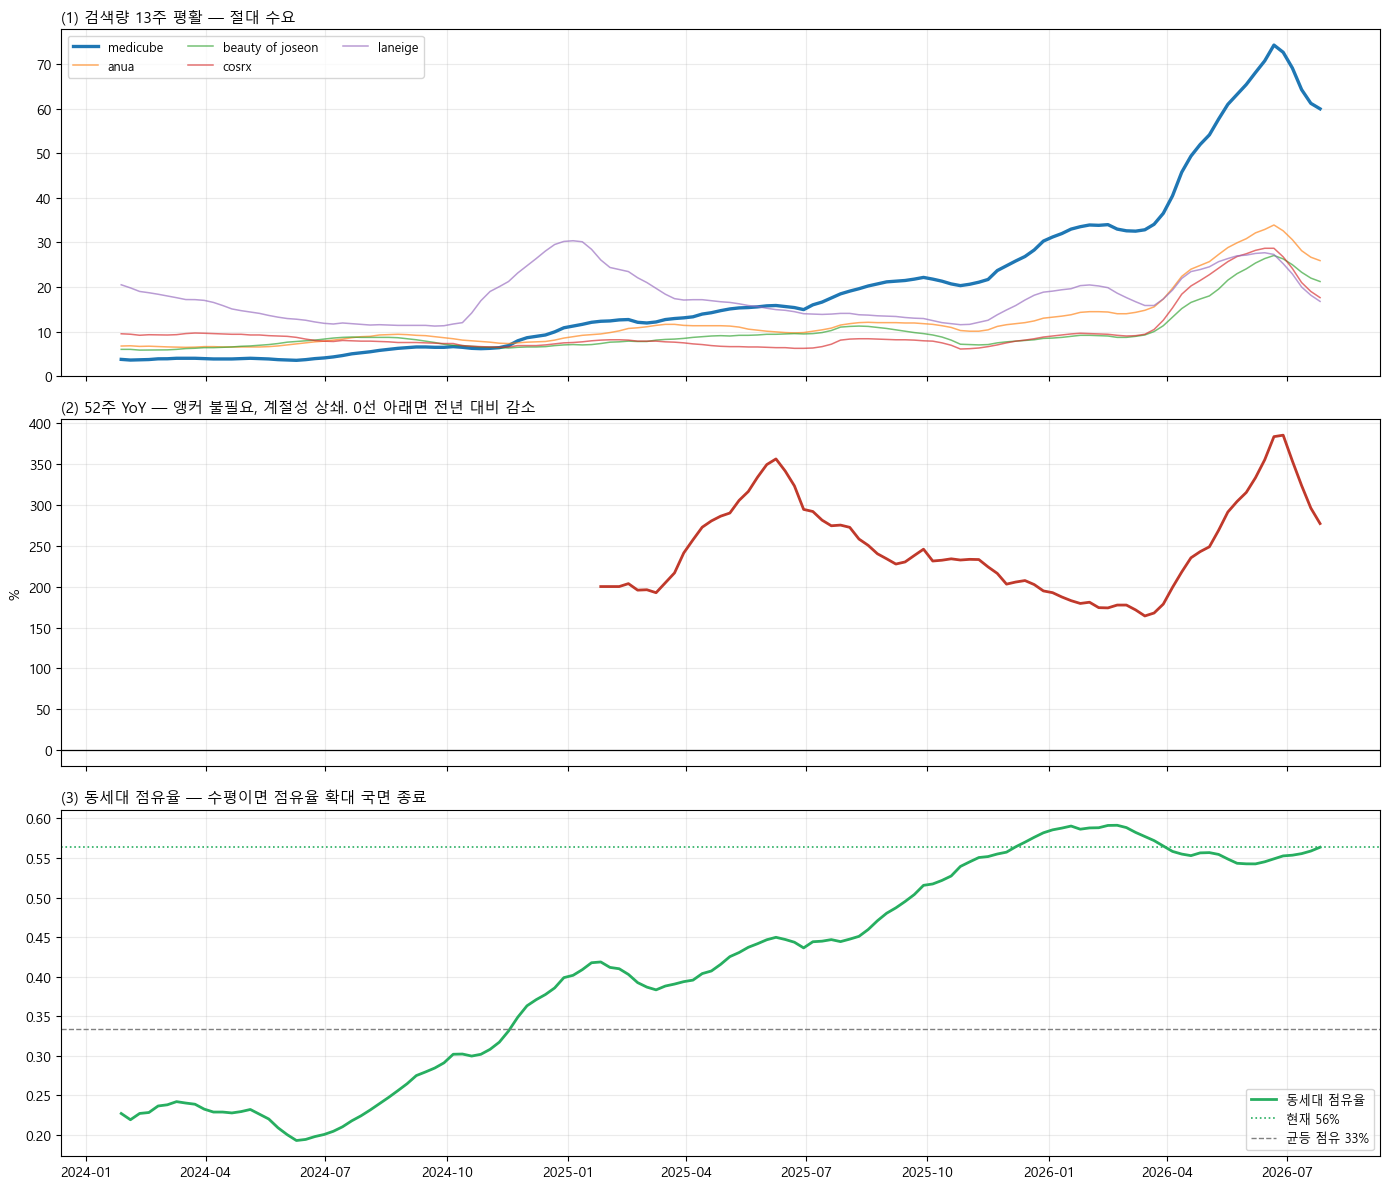

In [10]:
if SHOW_PLOTS:
    import matplotlib
    import matplotlib.pyplot as plt
    for _f in ["Malgun Gothic", "AppleGothic", "NanumGothic", "DejaVu Sans"]:
        try:
            matplotlib.rcParams["font.family"] = _f; break
        except Exception:
            continue
    matplotlib.rcParams["axes.unicode_minus"] = False

    fig, axes = plt.subplots(3, 1, figsize=(FIG_W, 12), sharex=True)

    ax = axes[0]
    for k in CALL_1:
        if k in v1.columns:
            lw = 2.4 if k == TARGET else 1.1
            ax.plot(v1.index, smooth(v1[k]), linewidth=lw, label=k,
                    alpha=1.0 if k == TARGET else 0.65)
    ax.set_title("(1) 검색량 %d주 평활 — 절대 수요" % SMOOTH_W, fontsize=11, loc="left")
    ax.legend(fontsize=9, ncol=3); ax.grid(alpha=0.25)

    ax = axes[1]
    ax.plot(met.index, met["yoy_sm"] * 100, color="#c0392b", linewidth=2.0)
    ax.axhline(0, color="black", linewidth=0.9)
    ax.set_ylabel("%")
    ax.set_title("(2) 52주 YoY — 앵커 불필요, 계절성 상쇄. 0선 아래면 전년 대비 감소",
                 fontsize=11, loc="left")
    ax.grid(alpha=0.25)

    ax = axes[2]
    ax.plot(met.index, met["sos_sm"], color="#27ae60", linewidth=2.0, label="동세대 점유율")
    if "sos_sm" in met.columns:
        last = met["sos_sm"].dropna()
        if len(last):
            ax.axhline(last.iloc[-1], color="#27ae60", linestyle=":", linewidth=1.2,
                       label="현재 %.0f%%" % (last.iloc[-1] * 100))
    ax.axhline(1.0 / (1 + len(peers_now)), color="grey", linestyle="--", linewidth=1.0,
               label="균등 점유 %.0f%%" % (100.0 / (1 + len(peers_now))))
    ax.set_title("(3) 동세대 점유율 — 수평이면 점유율 확대 국면 종료",
                 fontsize=11, loc="left")
    ax.legend(fontsize=9); ax.grid(alpha=0.25)

    plt.tight_layout(); plt.show()


---

## V2 → V3 변경 요약

| | V2 | V3 |
|---|---|---|
| 핵심 지표 | `medicube / skincare` (앵커 의존) | **원본값 52주 YoY** (앵커 프리) |
| 앵커 문제 | 앵커 CV 0.39, 분모가 결과를 지배 | 앵커 자체를 제거 |
| 점유율 판정 | 부호만 확인 → 오판 | **노이즈 대역(±3%) 도입** |
| 감쇠 템플릿 | 동세대만 → 동시 피크로 실패 | **1세대(COSRX·Laneige) 추가** |
| 유효 구간 | 전 구간 | 저볼륨 컷오프 구간 자동 배제 |
| 산출물 | 지표 나열 | **긍정/부정 팩트시트** |

## 콘텐츠 제작 시 유의

1. **양쪽을 다 제시하십시오.** 팩트시트가 긍정·부정을 나눠 출력하는 이유입니다.
   한쪽만 인용하면 데이터가 아니라 주장이 됩니다.
2. **"미국 검색량 기준" 단서를 떼지 마십시오.** 이 데이터는 APR 매출을 측정하지 않습니다.
3. **수치의 출처와 수집일을 밝히십시오.** 팩트시트 하단에 자동 출력됩니다.
4. **투자 권유로 읽히지 않도록 하십시오.** 이 노트북은 검색 수요를 측정할 뿐,
   적정 주가나 매수·매도 판단의 근거가 아닙니다.
5. 확정된 사실(공시 수출액)과 추정(검색 기반 해석)을 명확히 구분하십시오.

## 함께 볼 것

가장 강한 근거는 **공시 데이터**입니다. `apr_us_amazon_keepa_query_v5` 의 3장에서
분기 수출액과 내수/수출 비중이 나옵니다. 이건 감사받은 확정치이므로
검색 데이터보다 훨씬 단단한 인용 근거가 됩니다.

---
*V3 · 2026-08 · 짝 노트북: `apr_us_amazon_keepa_query_v5`*